# Inspect a generated scene

Phase 1 sanity-checking: build one T-joint, look at the numbers, plot the cloud and the
three D19 seam curves.

Run from the repo root (`weld_generator/`).

In [5]:
import sys, numpy as np
sys.path.insert(0, "..")            # notebooks/ -> weld_generator/

from weldgen.config import load_config
from weldgen.scene import generate_scene

SEED_NUMBER = 13

cfg = load_config("../configs/playground.yaml")
scene, arrays = generate_scene(cfg, seed=SEED_NUMBER)

print("scene_id ", scene["scene_id"])
print("twin_key ", scene["twin_key"])
print("quality  ", scene["joint"]["quality_level"])
print("included ", round(scene["joint"]["included_angle_deg"], 3), "deg")
print("root gap ", round(scene["fit"]["root_gap_mm"], 3), "mm")
print("points   ", scene["cloud"]["n_points"])

scene_id  bf32cbd5-0000000013
twin_key  81f7c40291680932
quality   B
included  0.0 deg
root gap  0.255 mm
points    78941


## Seams

A T-joint has two fillets (D5). `included_angle_deg` is one number for the scene, but the
two seams carry *different* dihedrals summing to 180 — that is D18's point that the two
quantities are not interchangeable.

In [6]:
# Weldable seams are the ground truth. The rest are kept ON PURPOSE as hard negatives
# (D22): real geometry that a detector would return but that is not this joint's weld.
weld     = [s for s in scene["seams"] if s["weldable"]]
rejected = [s for s in scene["seams"] if not s["weldable"]]

print(f'{scene["joint"]["type"]} joint  ->  {len(weld)} weldable, {len(rejected)} rejected\n')
print("WELDABLE (ground truth)")
for s in weld:
    print(f'  seam {s["id"]:>2}  {str(s["face_pair"]):<22} {s["seam_class"]:<8} '
          f'len={s["length_mm"]:8.2f} mm  dihedral={s["dihedral_deg"]:6.2f}')
print("\nREJECTED (negatives, not ground truth)")
for s in rejected:
    print(f'  seam {s["id"]:>2}  {str(s["face_pair"]):<22} {s["seam_class"]:<8} '
          f'len={s["length_mm"]:8.2f} mm  <- {s["reject_reason"]}')

edge joint  ->  3 weldable, 7 rejected

WELDABLE (ground truth)
  seam  0  ['A:s2', 'B:s1']       edge     len=  177.25 mm  dihedral=180.00
  seam  1  ['A:+w', 'B:s0']       lap_toe  len=  134.12 mm  dihedral= 90.00
  seam  2  ['A:+w', 'B:s2']       lap_toe  len=   84.66 mm  dihedral= 90.00

REJECTED (negatives, not ground truth)
  seam  3  ['A:+w', 'B:s1']       lap_toe  len=  177.25 mm  <- toe_of_centreline
  seam  4  ['A:s0', 'B:-w']       lap_toe  len=   32.07 mm  <- bisector_blocked
  seam  5  ['A:s0', 'F:+w']       lap_toe  len=  233.33 mm  <- fixture_contact
  seam  6  ['A:s1', 'F:+w']       lap_toe  len=  104.72 mm  <- fixture_contact
  seam  7  ['A:s2', 'B:-w']       lap_toe  len=  177.25 mm  <- bisector_blocked
  seam  8  ['A:s2', 'F:+w']       lap_toe  len=  280.83 mm  <- fixture_contact
  seam  9  ['A:s3', 'F:+w']       lap_toe  len=   63.35 mm  <- fixture_contact


## D19: the three seam definitions

The stored curve is `nominal`. `root` and `gap_mid` ship as derived arrays so the
conversion is a subtraction, not a re-derivation. At a right angle the offsets are
`0`, `g/2`, `g` — but that closed form does not survive a sampled included angle.

In [7]:
g = scene["fit"]["root_gap_mm"]
for s in scene["seams"]:
    if not s["weldable"]:
        continue                      # negatives carry the curves too, but they are not GT
    i = s["id"]
    nom  = arrays[f"seams.npz:seam_{i}"]
    root = arrays[f"seams.npz:seam_{i}_root"]
    mid   = arrays[f"seams.npz:seam_{i}_gapmid"]
    print(f'seam {i} [{s["seam_class"]}]:  |root-nom| = {np.linalg.norm(root[0]-nom[0]):.4f}   '
          f'|mid-nom| = {np.linalg.norm(mid[0]-nom[0]):.4f}   (g = {g:.4f})')

seam 0 [edge]:  |root-nom| = 0.1274   |mid-nom| = 0.0000   (g = 0.2548)
seam 1 [lap_toe]:  |root-nom| = 0.2548   |mid-nom| = 0.1274   (g = 0.2548)
seam 2 [lap_toe]:  |root-nom| = 0.2548   |mid-nom| = 0.1274   (g = 0.2548)


## Plot

**The scene is placed at a sampled world pose** (random yaw + translation, deliberately —
SCHEMA.md §1.1, so nothing about the joint leaks from the world axes). So slicing on world
X and plotting world (y, z) is *not* a cross-section of anything: the markers land at
arbitrary spots and move with every seed.

`weldgen.viz.assembly_frame` undoes the pose. In that frame A's top face is `z = 0`, B
stands at `y >= 0` starting at `z = g`, and the seam runs along `+X` — so the cross-section
is the canonical drawing every time.

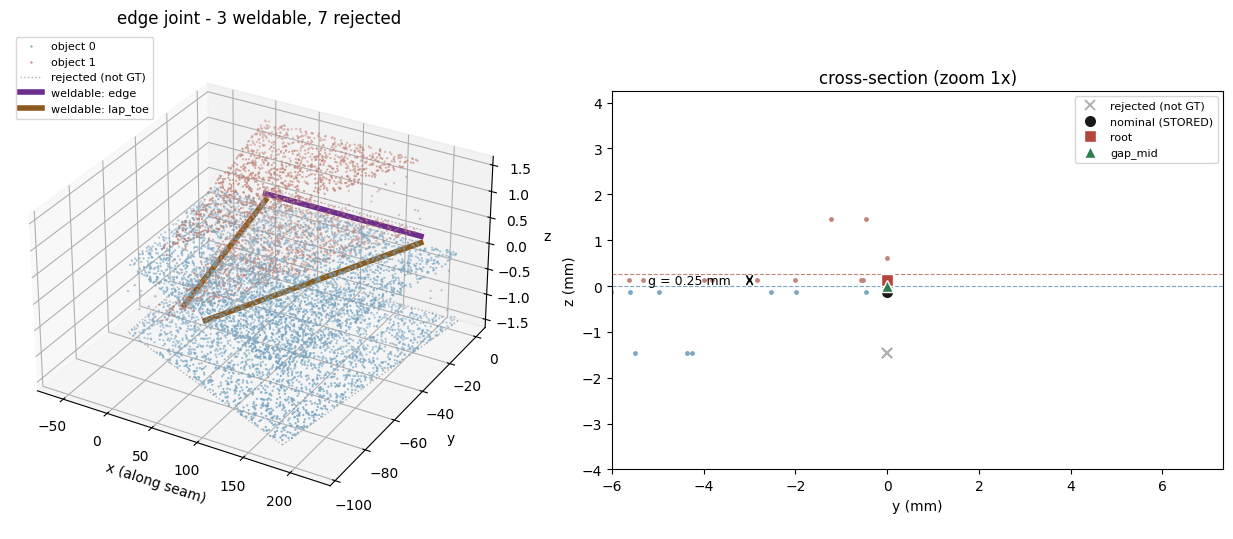

In [ ]:
import matplotlib.pyplot as plt
from weldgen.viz import assembly_frame, cross_section, to_assembly

# Rejected seams are kept in the file on purpose (D22) - real geometry that is NOT this
# joint's weld. Drawing them the same as ground truth is misleading, so they are pale and
# dashed here. Set SHOW_REJECTED = False to see the ground truth alone.
SHOW_REJECTED = True
ZOOM = 1          # ZOOM < 1 zooms in; 0.5 shows 50% of the tight-fit area

T   = assembly_frame(scene)                    # world -> assembly
xyz = to_assembly(arrays["cloud.npz:xyz"], T)
oid = arrays["cloud.npz:object_id"]
g   = scene["fit"]["root_gap_mm"]
t_B = next(o for o in scene["objects"] if o["id"] == "B")["thickness_mm"]

weld     = [s for s in scene["seams"] if s["weldable"]]
rejected = [s for s in scene["seams"] if not s["weldable"]]
CLASS_C  = {"fillet": "#1a1a1a", "butt": "#1f6f8b", "lap_toe": "#8b5a1f", "edge": "#6b2f8b"}

fig = plt.figure(figsize=(13, 5.5))

# ---- 3D -------------------------------------------------------------------------
ax = fig.add_subplot(121, projection="3d")
for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
    m = oid == o
    ax.scatter(xyz[m, 0], xyz[m, 1], xyz[m, 2], s=0.4, c=c, label=f"object {o}")

if SHOW_REJECTED:
    for k, s in enumerate(rejected):
        q = to_assembly(arrays[f'seams.npz:seam_{s["id"]}'], T)
        ax.plot(q[:, 0], q[:, 1], q[:, 2], lw=1.0, ls=":", c="#b0b0b0",
                label="rejected (not GT)" if k == 0 else None)

seen = set()
for s in weld:
    q = to_assembly(arrays[f'seams.npz:seam_{s["id"]}'], T)
    cl = s["seam_class"]
    ax.plot(q[:, 0], q[:, 1], q[:, 2], lw=4.0, c=CLASS_C.get(cl, "#1a1a1a"),
            label=None if cl in seen else f"weldable: {cl}")
    seen.add(cl)

ax.set_box_aspect([1, 1, 0.6]); ax.legend(loc="upper left", fontsize=8)
ax.set_xlabel("x (along seam)"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f'{scene["joint"]["type"]} joint - {len(weld)} weldable, {len(rejected)} rejected')

# ---- cross-section, zoomed on the joint ------------------------------------------
ax2 = fig.add_subplot(122)
band = cross_section(xyz, half_width_mm=3.0)
for o, c in ((0, "#7aa6c2"), (1, "#c2857a")):
    m = band & (oid == o)
    ax2.scatter(xyz[m, 1], xyz[m, 2], s=6, c=c)

if SHOW_REJECTED:
    for k, s in enumerate(rejected):
        q = to_assembly(arrays[f'seams.npz:seam_{s["id"]}'], T)
        ax2.plot(q[0, 1], q[0, 2], "x", ms=7, c="#b0b0b0", mew=1.4,
                 label="rejected (not GT)" if k == 0 else None, zorder=3)

styles = {"": ("o", "#1a1a1a", "nominal (STORED)"),
          "_root": ("s", "#b5453b", "root"),
          "_gapmid": ("^", "#2f7d4f", "gap_mid")}
first = True
for s in weld:                                  # ground truth only
    for key, (mk, c, lab) in styles.items():
        q = to_assembly(arrays[f'seams.npz:seam_{s["id"]}{key}'], T)
        ax2.plot(q[0, 1], q[0, 2], mk, ms=9, c=c, mec="white", mew=1.0,
                 label=lab if first else None, zorder=5)
    first = False

ax2.axhline(0.0, lw=0.8, ls="--", c="#7aa6c2")   # A top face
ax2.axhline(g,   lw=0.8, ls="--", c="#c2857a")   # B bottom face
ax2.annotate("", xy=(-3, 0), xytext=(-3, g), arrowprops=dict(arrowstyle="<->", lw=1.2))
ax2.text(-3.4, g / 2, f"g = {g:.2f} mm", ha="right", va="center", fontsize=9)

pad = max(4.0 * g, 4.0)
x_lo, x_hi = -6.0, t_B + 6.0
y_lo, y_hi = -pad, pad + g
xc, yc = 0.5 * (x_lo + x_hi), 0.5 * (y_lo + y_hi)
ax2.set_xlim(xc - ZOOM * (xc - x_lo), xc + ZOOM * (x_hi - xc))
ax2.set_ylim(yc - ZOOM * (yc - y_lo), yc + ZOOM * (y_hi - yc))
ax2.set_aspect("equal"); ax2.set_xlabel("y (mm)"); ax2.set_ylabel("z (mm)")
ax2.legend(loc="upper right", fontsize=8); ax2.set_title(f"cross-section (zoom {ZOOM:g}x)")
plt.tight_layout()

### Reading the cross-section

The two fillets sit at `y = 0` and `y = t_B` — the two faces of the standing plate. At each:

* **nominal** (stored) on A's top face, `z = 0` — where the extended planes meet
* **gap_mid** at `z = g/2`, exactly midway between A's top face and B's bottom face
* **root** at `z = g`, B's bottom edge — the innermost corner of the joint

The spread between them is `O(g)`, which at the reference 1,1 mm gap is larger than the
~0,6 mm RMSE the literature reports. That is the whole reason D19 exists.

In [12]:
# What the D19 triple means depends on the seam class:
#   fillet / lap_toe  - the faces meet at an angle, so nominal / gap_mid / root are three
#                       distinct curves offset by 0, g/2, g.
#   butt / edge       - the seam IS the gap centreline, so `nominal` and `gap_mid` coincide
#                       and `root` is the nearer face edge at g/2. The triple degenerates,
#                       which is correct, not a bug.
for s in scene["seams"]:
    if not s["weldable"]:
        continue
    i, cl = s["id"], s["seam_class"]
    n = to_assembly(arrays[f"seams.npz:seam_{i}"], T)[0]
    r = to_assembly(arrays[f"seams.npz:seam_{i}_root"], T)[0]
    m = to_assembly(arrays[f"seams.npz:seam_{i}_gapmid"], T)[0]
    if cl in ("butt", "edge"):
        exp = f"centreline: gap_mid == nominal (0), root = g/2 = {g/2:.4f}"
    else:
        exp = f"angled: gap_mid = g/2 = {g/2:.4f}, root = g = {g:.4f}"
    print(f'seam {i} {tuple(s["face_pair"])} [{cl}]')
    print(f'    |gap_mid - nominal| = {np.linalg.norm(m - n):7.4f}')
    print(f'    |root    - nominal| = {np.linalg.norm(r - n):7.4f}     expect {exp}')

seam 0 ('A:s2', 'B:s3') [edge]
    |gap_mid - nominal| =  0.0000
    |root    - nominal| =  0.1216     expect centreline: gap_mid == nominal (0), root = g/2 = 0.1216
seam 1 ('A:+w', 'B:s1') [lap_toe]
    |gap_mid - nominal| =  0.1216
    |root    - nominal| =  0.2431     expect angled: gap_mid = g/2 = 0.1216, root = g = 0.2431
seam 2 ('A:+w', 'B:s2') [lap_toe]
    |gap_mid - nominal| =  0.1216
    |root    - nominal| =  0.2431     expect angled: gap_mid = g/2 = 0.1216, root = g = 0.2431


## Determinism

The Phase 1 gate (D15). The content hash is defined on *content*, not file bytes —
`np.savez` embeds zip timestamps, so byte-identity is unachievable.

In [13]:
from weldgen.hashing import content_hash

a = content_hash(*generate_scene(cfg, SEED_NUMBER))
b = content_hash(*generate_scene(cfg, SEED_NUMBER))
print(a)
print("repeatable:", a == b)

# provenance is excluded, so re-running next month still matches
sc, ar = generate_scene(cfg, SEED_NUMBER)
sc["provenance"]["created_utc"] = "1999-01-01T00:00:00Z"
print("provenance-independent:", content_hash(sc, ar) == a)

2426f3d084a4293eda3cdce20fe6eba69009b5762dccd75b0dcaf51cc5c51723
repeatable: True
provenance-independent: True
